# RQ7 — Journal-Strong External Generalization Analysis

## Reframed RQ7

**RQ7-strong:** *To what extent do the portable components of the proposed lightweight legal-document framework maintain predictive value across independent legal datasets, and how large is the external generalization gap between CUAD and selected LexGLUE tasks?*

This version is stronger and safer for a journal paper because it avoids the weak claim that a CUAD-trained model directly transfers to LexGLUE despite incompatible label spaces. Instead, it tests **external validity** under controlled, repeatable conditions:

1. **Same pipeline, different legal datasets**: CUAD, LEDGAR, and UNFAIR-ToS are evaluated using the same modeling protocol.
2. **Strong baselines**: majority/frequency baseline, TF-IDF, TF-IDF + portable structural features, SBERT, and SBERT + portable structural features.
3. **Repeated splits**: multiple random seeds are used to estimate stability.
4. **Dataset controls**: label filtering, top-label restriction, and optional sample-size balancing.
5. **Normalized improvement**: each model is compared not only by raw Macro-F1, but also by improvement over the majority baseline.
6. **Generalization gap analysis**: performance differences from CUAD are quantified.
7. **Domain-shift diagnostics**: SBERT centroid distances estimate how semantically different the datasets are.

### Journal-safe interpretation

This notebook does **not** claim that CUAD labels and LexGLUE labels are identical.  
It evaluates whether the **portable text/semantic/structural components** of the framework remain useful across related legal NLP tasks.

In [1]:
# ============================================================
# RQ7 Journal-Strong Setup
# Uses ONLY local datasets and local SBERT model.
#
# Expected local structure:
# C:\Users\a2510\Desktop\new_code\
#   ├── cuad\
#   ├── lex_glue\
#   └── all-MiniLM-L6-v2\
# ============================================================

from pathlib import Path
import os, re, json, random, math, warnings, statistics
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import hstack, csr_matrix
from scipy.stats import spearmanr
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, f1_score
)
from sklearn.metrics.pairwise import cosine_similarity

try:
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except Exception:
    DEVICE = "cpu"

try:
    from sentence_transformers import SentenceTransformer
except Exception:
    SentenceTransformer = None

try:
    from datasets import load_from_disk, Dataset
except Exception:
    load_from_disk = None
    Dataset = None

RANDOM_SEEDS = [13, 21, 42, 87, 101]
BASE_DIR = Path(r"C:\Users\a2510\Desktop\new_code")
CUAD_DIR = BASE_DIR / "cuad"
LEX_DIR = BASE_DIR / "lex_glue"
MODEL_DIR = BASE_DIR / "all-MiniLM-L6-v2"

OUT_DIR = BASE_DIR / "rq7_journal_strong_outputs"
CSV_DIR = OUT_DIR / "csv"
FIG_DIR = OUT_DIR / "figures"
for d in [OUT_DIR, CSV_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Device:", DEVICE)
print("CUAD_DIR:", CUAD_DIR)
print("LEX_DIR:", LEX_DIR)
print("MODEL_DIR:", MODEL_DIR)
print("Output:", OUT_DIR)

Device: cuda
CUAD_DIR: C:\Users\a2510\Desktop\new_code\cuad
LEX_DIR: C:\Users\a2510\Desktop\new_code\lex_glue
MODEL_DIR: C:\Users\a2510\Desktop\new_code\all-MiniLM-L6-v2
Output: C:\Users\a2510\Desktop\new_code\rq7_journal_strong_outputs


In [2]:
# ============================================================
# Utility functions
# ============================================================

def clean_text(x):
    if x is None:
        return ""
    if isinstance(x, float) and pd.isna(x):
        return ""
    x = str(x).replace("\x00", " ")
    x = re.sub(r"\s+", " ", x)
    return x.strip()

def normalize_label(label):
    label = clean_text(label)
    m = re.search(r'"([^"]+)"', label)
    if m:
        return clean_text(m.group(1))
    label = re.sub(r"(?i)^highlight the parts.*?related to", "", label)
    label = re.sub(r"(?i)that should be reviewed by a lawyer.*$", "", label)
    label = label.strip(" .:-")
    return label if label else "Unknown"

def savecsv(df, filename):
    path = CSV_DIR / filename
    df.to_csv(path, index=False, encoding="utf-8-sig")
    print("Saved CSV:", path)
    return path

def savefig(filename):
    path = FIG_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved figure:", path)
    return path

def find_files(root, suffixes):
    root = Path(root)
    files = []
    if not root.exists():
        return files
    for suf in suffixes:
        files.extend(list(root.rglob(f"*{suf}")))
    return files

def pick_column(cols, candidates):
    cols = list(cols)
    lower = {str(c).lower(): c for c in cols}
    for cand in candidates:
        if cand.lower() in lower:
            return lower[cand.lower()]
    for c in cols:
        lc = str(c).lower()
        if any(cand.lower() in lc for cand in candidates):
            return c
    return None

def dataframe_from_hf_dataset(ds):
    frames = []
    if hasattr(ds, "keys") and not isinstance(ds, list):
        for split in ds.keys():
            try:
                frames.append(ds[split].to_pandas())
            except Exception:
                pass
    else:
        try:
            frames.append(ds.to_pandas())
        except Exception:
            pass
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

def metric_row(y_true, y_pred, model, dataset, seed):
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    return {
        "dataset": dataset,
        "model": model,
        "seed": seed,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": p,
        "macro_recall": r,
        "macro_f1": f1,
        "micro_f1": f1_score(y_true, y_pred, average="micro")
    }

def summarize_repeated(metrics_df):
    rows = []
    for (dataset, model), g in metrics_df.groupby(["dataset", "model"]):
        row = {"dataset": dataset, "model": model, "n_splits": len(g)}
        for col in ["accuracy", "macro_precision", "macro_recall", "macro_f1", "micro_f1"]:
            row[f"{col}_mean"] = g[col].mean()
            row[f"{col}_std"] = g[col].std(ddof=1) if len(g) > 1 else 0.0
            row[f"{col}_ci95"] = 1.96 * row[f"{col}_std"] / math.sqrt(max(1, len(g)))
        rows.append(row)
    return pd.DataFrame(rows).sort_values(["dataset", "macro_f1_mean"], ascending=[True, False])

def prepare_dataset_for_classification(df, dataset_name, min_per_label=8, max_labels=25, max_samples_per_label=None):
    data = df.copy()
    data["text"] = data["text"].apply(clean_text)
    data["label"] = data["label"].apply(clean_text)
    data = data[(data["text"].str.len() > 0) & (data["label"].str.len() > 0)]

    vc = data["label"].value_counts()
    keep = vc[vc >= min_per_label].head(max_labels).index
    data = data[data["label"].isin(keep)].copy()

    if max_samples_per_label is not None:
        data = (
            data.groupby("label", group_keys=False)
            .apply(lambda x: x.sample(min(len(x), max_samples_per_label), random_state=42))
            .reset_index(drop=True)
        )

    data = data.sample(frac=1, random_state=42).reset_index(drop=True)
    if data["label"].nunique() < 2:
        raise ValueError(f"{dataset_name}: not enough labels after filtering.")
    return data

In [3]:
# ============================================================
# Robust local dataset loaders
# ============================================================

def load_cuad_samples(cuad_dir=CUAD_DIR, min_len=20):
    """
    Loads real local CUAD data.
    Supports:
    1) HuggingFace load_from_disk Arrow format
    2) CSV/XLSX
    3) SQuAD-style JSON
    Output: dataset, contract_id, text, label, raw_label
    """
    cuad_dir = Path(cuad_dir)
    rows = []

    if load_from_disk is not None and (cuad_dir / "dataset_info.json").exists():
        try:
            ds = load_from_disk(str(cuad_dir))
            hdf = dataframe_from_hf_dataset(ds)
            if len(hdf) > 0:
                text_col = pick_column(hdf.columns, ["answers", "answer", "text", "context", "clause", "clause_text"])
                label_col = pick_column(hdf.columns, ["question", "label", "category", "clause_category"])
                contract_col = pick_column(hdf.columns, ["title", "contract", "contract_id", "document", "filename"])

                parsed = []
                for _, r in hdf.iterrows():
                    contract_id = clean_text(r[contract_col]) if contract_col else "hf_contract"
                    raw_label = clean_text(r[label_col]) if label_col else "Unknown"
                    label = normalize_label(raw_label)

                    val = r[text_col] if text_col else ""
                    if isinstance(val, dict) and "text" in val:
                        texts = val["text"]
                        if not isinstance(texts, list):
                            texts = [texts]
                    elif isinstance(val, list):
                        texts = val
                    else:
                        texts = [val]

                    if not texts or all(len(clean_text(t)) < min_len for t in texts):
                        if "context" in hdf.columns:
                            texts = [r["context"]]

                    for t in texts:
                        t = clean_text(t)
                        if len(t) >= min_len:
                            parsed.append({
                                "dataset": "CUAD",
                                "contract_id": contract_id,
                                "text": t,
                                "raw_label": raw_label,
                                "label": label
                            })
                if parsed:
                    rows.append(pd.DataFrame(parsed))
        except Exception as e:
            print("HF CUAD loading failed, trying files:", e)

    for fp in find_files(cuad_dir, [".csv", ".xlsx", ".xls"]):
        try:
            df = pd.read_csv(fp) if fp.suffix.lower()==".csv" else pd.read_excel(fp)
        except Exception:
            continue
        text_col = pick_column(df.columns, ["answer", "answers", "clause", "clause_text", "text", "context", "excerpt", "span"])
        label_col = pick_column(df.columns, ["category", "clause_category", "label", "question", "clause type", "clause_type"])
        contract_col = pick_column(df.columns, ["contract", "contract_id", "document", "document_id", "file", "filename", "title"])
        if text_col and label_col:
            tmp = pd.DataFrame()
            tmp["dataset"] = "CUAD"
            tmp["text"] = df[text_col].apply(clean_text)
            tmp["raw_label"] = df[label_col].apply(clean_text)
            tmp["label"] = tmp["raw_label"].apply(normalize_label)
            tmp["contract_id"] = df[contract_col].astype(str) if contract_col else fp.stem
            tmp = tmp[(tmp["text"].str.len() >= min_len) & (tmp["label"].str.len() > 0)]
            if len(tmp):
                rows.append(tmp[["dataset", "contract_id", "text", "raw_label", "label"]])

    for fp in find_files(cuad_dir, [".json"]):
        try:
            obj = json.loads(fp.read_text(encoding="utf-8"))
        except Exception:
            try:
                obj = json.loads(fp.read_text(encoding="latin-1"))
            except Exception:
                continue
        if not isinstance(obj, dict) or "data" not in obj:
            continue
        parsed = []
        for doc in obj.get("data", []):
            contract_id = clean_text(doc.get("title", fp.stem))
            for para in doc.get("paragraphs", []):
                for qa in para.get("qas", []):
                    raw_label = clean_text(qa.get("question", qa.get("id", "Unknown")))
                    label = normalize_label(raw_label)
                    for ans in qa.get("answers", []):
                        t = clean_text(ans.get("text", ""))
                        if len(t) >= min_len:
                            parsed.append({
                                "dataset": "CUAD",
                                "contract_id": contract_id,
                                "text": t,
                                "raw_label": raw_label,
                                "label": label
                            })
        if parsed:
            rows.append(pd.DataFrame(parsed))

    if not rows:
        raise FileNotFoundError(f"No usable CUAD samples found in {cuad_dir}. Check folder format.")

    data = pd.concat(rows, ignore_index=True).drop_duplicates()
    data = data[(data["text"].str.len() >= min_len) & (data["label"].str.len() > 0)]
    data = data.reset_index(drop=True)

    print("Loaded real CUAD samples:", data.shape)
    print("Unique short labels:", data["label"].nunique())
    print("Unique contracts:", data["contract_id"].nunique())
    print(data["label"].value_counts().head(10))
    return data

def load_lexglue_samples(lex_dir=LEX_DIR, subset_keywords=("ledgar", "unfair_tos"), min_len=10):
    """
    Robust LexGLUE local loader.
    Output columns: dataset, subset, contract_id, text, label
    """
    lex_dir = Path(lex_dir)
    rows = []

    def _standardize_df(df, subset_name):
        if df is None or len(df) == 0:
            return None

        text_col = pick_column(
            df.columns,
            ["text", "sentence", "paragraph", "provision", "clause", "context", "premise"]
        )
        label_col = pick_column(
            df.columns,
            ["label", "labels", "category", "answer", "class"]
        )

        print(f"\nChecking LexGLUE subset/file: {subset_name}")
        print("Columns:", list(df.columns))
        print("Detected text_col:", text_col)
        print("Detected label_col:", label_col)

        if text_col is None or label_col is None:
            return None

        tmp = pd.DataFrame({
            "dataset": f"LexGLUE_{subset_name}",
            "subset": subset_name,
            "contract_id": [f"{subset_name}_{i}" for i in range(len(df))],
            "text": df[text_col].apply(clean_text),
            "label": df[label_col].astype(str).apply(clean_text)
        })

        tmp = tmp[(tmp["text"].str.len() >= min_len) & (tmp["label"].str.len() > 0)]
        return tmp if len(tmp) > 0 else None

    subset_folders = []
    for key in subset_keywords:
        p = lex_dir / key
        if p.exists():
            subset_folders.append(p)

    for p in lex_dir.rglob("*") if lex_dir.exists() else []:
        if p.is_dir():
            low = str(p).lower()
            if any(k.lower() in low for k in subset_keywords):
                subset_folders.append(p)

    subset_folders = list(dict.fromkeys(subset_folders))
    print("Candidate LexGLUE folders:")
    for p in subset_folders:
        print(" -", p)

    if load_from_disk is not None:
        for folder in subset_folders:
            try:
                ds = load_from_disk(str(folder))
                print("\nLoaded with load_from_disk:", folder)
                if hasattr(ds, "keys"):
                    for split in ds.keys():
                        try:
                            df = ds[split].to_pandas()
                            tmp = _standardize_df(df, f"{folder.name}_{split}")
                            if tmp is not None:
                                rows.append(tmp)
                        except Exception as e:
                            print("Split failed:", split, e)
                else:
                    df = ds.to_pandas()
                    tmp = _standardize_df(df, folder.name)
                    if tmp is not None:
                        rows.append(tmp)
            except Exception as e:
                print("load_from_disk failed for", folder, ":", e)

    if lex_dir.exists():
        for pattern in ["*.parquet", "*.csv", "*.jsonl", "*.json"]:
            for fp in lex_dir.rglob(pattern):
                low = str(fp).lower()
                if not any(k.lower() in low for k in subset_keywords):
                    continue
                try:
                    if fp.suffix.lower() == ".parquet":
                        df = pd.read_parquet(fp)
                    elif fp.suffix.lower() == ".csv":
                        df = pd.read_csv(fp)
                    elif fp.suffix.lower() == ".jsonl":
                        df = pd.read_json(fp, lines=True)
                    elif fp.suffix.lower() == ".json":
                        obj = json.loads(fp.read_text(encoding="utf-8"))
                        if isinstance(obj, list):
                            df = pd.DataFrame(obj)
                        elif isinstance(obj, dict) and "data" in obj and isinstance(obj["data"], list):
                            df = pd.DataFrame(obj["data"])
                        else:
                            continue
                    else:
                        continue

                    tmp = _standardize_df(df, fp.parent.name)
                    if tmp is not None:
                        rows.append(tmp)

                except Exception as e:
                    print("File loading failed:", fp, e)

    if Dataset is not None and lex_dir.exists():
        for fp in lex_dir.rglob("*.arrow"):
            low = str(fp).lower()
            if not any(k.lower() in low for k in subset_keywords):
                continue
            try:
                ds = Dataset.from_file(str(fp))
                df = ds.to_pandas()
                tmp = _standardize_df(df, fp.parent.name)
                if tmp is not None:
                    rows.append(tmp)
            except Exception as e:
                print("Arrow loading failed:", fp, e)

    if not rows:
        raise FileNotFoundError(
            f"No usable LexGLUE samples found in {lex_dir}. Check actual files inside ledgar/unfair_tos."
        )

    data = pd.concat(rows, ignore_index=True).drop_duplicates().reset_index(drop=True)
    print("\nLoaded LexGLUE samples:", data.shape)
    print(data["dataset"].value_counts().head(20))
    return data

In [4]:
# ============================================================
# Portable structural features and SBERT helper
# These are intentionally dataset-portable: they do not require PDF images,
# bounding boxes, or CUAD-specific annotations.
# ============================================================

SBERT_MODEL = None

def get_sbert_model():
    global SBERT_MODEL
    if SBERT_MODEL is not None:
        return SBERT_MODEL
    if SentenceTransformer is None:
        raise ImportError("sentence-transformers is missing. Run: pip install sentence-transformers")
    if not MODEL_DIR.exists():
        raise FileNotFoundError(f"Local SBERT model folder not found: {MODEL_DIR}")
    SBERT_MODEL = SentenceTransformer(str(MODEL_DIR), device=DEVICE)
    return SBERT_MODEL

def extract_portable_structure(df):
    texts = df["text"].fillna("").astype(str)

    feat = pd.DataFrame({
        "length_chars": texts.str.len(),
        "length_words": texts.apply(lambda x: len(x.split())),
        "sentence_count": texts.apply(lambda x: max(1, len(re.findall(r"[.!?;]", x)))),
        "uppercase_ratio": texts.apply(lambda x: sum(ch.isupper() for ch in x) / max(1, len(x))),
        "digit_ratio": texts.apply(lambda x: sum(ch.isdigit() for ch in x) / max(1, len(x))),
        "has_numbering": texts.str.contains(r"(^|\s)(\d+(\.\d+)*|\([a-zA-Z0-9]+\)|[ivx]+\.)", case=False, regex=True).astype(int),
        "has_heading_keyword": texts.str.contains(r"\b(section|article|clause|schedule|exhibit|annex|appendix|agreement|terms?)\b", case=False, regex=True).astype(int),
        "has_signature_keyword": texts.str.contains(r"\b(signature|signed|witness|executed|signatory)\b", case=False, regex=True).astype(int),
        "has_date": texts.str.contains(r"\b(\d{1,2}[/-]\d{1,2}[/-]\d{2,4}|\d{4}[/-]\d{1,2}[/-]\d{1,2}|january|february|march|april|may|june|july|august|september|october|november|december)\b", case=False, regex=True).astype(int),
        "has_money": texts.str.contains(r"(\$|€|£|usd|eur|gbp|dollars?|euros?|pounds?)", case=False, regex=True).astype(int),
        "has_percentage": texts.str.contains(r"\d+(\.\d+)?\s?%", regex=True).astype(int),
        "contains_negation": texts.str.contains(r"\b(no|not|without|unless|except|excluding|prohibited)\b", case=False, regex=True).astype(int),
        "contains_obligation": texts.str.contains(r"\b(shall|must|required|obligated|agree|undertake|warrant)\b", case=False, regex=True).astype(int),
        "contains_right": texts.str.contains(r"\b(right|entitled|may|permission|license)\b", case=False, regex=True).astype(int),
    })
    return feat.fillna(0)

def split_data(data, seed, dataset_name):
    """
    CUAD uses contract-level group split when contract_id is available.
    LexGLUE uses stratified split because each example is usually independent.
    """
    y = data["label"].astype(str)
    if dataset_name == "CUAD" and "contract_id" in data.columns and data["contract_id"].nunique() >= 5:
        splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
        train_idx, test_idx = next(splitter.split(data, y, groups=data["contract_id"].astype(str)))
        return train_idx, test_idx, "contract_group_split"
    else:
        train_idx, test_idx = train_test_split(
            np.arange(len(data)),
            test_size=0.2,
            random_state=seed,
            stratify=y
        )
        return train_idx, test_idx, "stratified_split"

In [5]:
# ============================================================
# Load data and save dataset statistics
# ============================================================

cuad = load_cuad_samples()
lex = load_lexglue_samples(subset_keywords=("ledgar", "unfair_tos"))

all_datasets = {"CUAD": cuad[["dataset", "contract_id", "text", "label"]].copy()}
for ds_name, g in lex.groupby("dataset"):
    all_datasets[ds_name] = g[["dataset", "contract_id", "text", "label"]].copy()

stats_rows = []
for name, df in all_datasets.items():
    stats_rows.append({
        "dataset": name,
        "n_samples_raw": len(df),
        "n_labels_raw": df["label"].nunique(),
        "median_text_length_words": df["text"].apply(lambda x: len(str(x).split())).median(),
        "mean_text_length_words": df["text"].apply(lambda x: len(str(x).split())).mean(),
        "n_contracts_or_examples": df["contract_id"].nunique() if "contract_id" in df.columns else len(df)
    })

stats_df = pd.DataFrame(stats_rows)
display(stats_df)
savecsv(stats_df, "rq7_dataset_statistics_raw.csv")

for name, df in all_datasets.items():
    safe_name = re.sub(r"[^A-Za-z0-9_]+", "_", name)
    savecsv(df.head(500), f"rq7_{safe_name}_loaded_preview.csv")

Loaded real CUAD samples: (11734, 5)
Unique short labels: 41
Unique contracts: 510
label
Parties                      1121
License Grant                 774
Cap On Liability              672
Anti-Assignment               651
Audit Rights                  642
Insurance                     558
Expiration Date               464
Governing Law                 462
Post-Termination Services     449
Document Name                 441
Name: count, dtype: int64
Candidate LexGLUE folders:
 - C:\Users\a2510\Desktop\new_code\lex_glue\ledgar
 - C:\Users\a2510\Desktop\new_code\lex_glue\unfair_tos
load_from_disk failed for C:\Users\a2510\Desktop\new_code\lex_glue\ledgar : Directory C:\Users\a2510\Desktop\new_code\lex_glue\ledgar is neither a `Dataset` directory nor a `DatasetDict` directory.
load_from_disk failed for C:\Users\a2510\Desktop\new_code\lex_glue\unfair_tos : Directory C:\Users\a2510\Desktop\new_code\lex_glue\unfair_tos is neither a `Dataset` directory nor a `DatasetDict` directory.

Checkin

,dataset,n_samples_raw,n_labels_raw,median_text_length_words,mean_text_length_words,n_contracts_or_examples
0,CUAD,11734,41,38.0,47.582069,510
1,LexGLUE_ledgar,80000,100,84.0,112.982000,60000
2,LexGLUE_unfair_tos,9414,22,27.0,32.704376,5532


Saved CSV: C:\Users\a2510\Desktop\new_code\rq7_journal_strong_outputs\csv\rq7_dataset_statistics_raw.csv
Saved CSV: C:\Users\a2510\Desktop\new_code\rq7_journal_strong_outputs\csv\rq7_CUAD_loaded_preview.csv
Saved CSV: C:\Users\a2510\Desktop\new_code\rq7_journal_strong_outputs\csv\rq7_LexGLUE_ledgar_loaded_preview.csv
Saved CSV: C:\Users\a2510\Desktop\new_code\rq7_journal_strong_outputs\csv\rq7_LexGLUE_unfair_tos_loaded_preview.csv


In [7]:
# ============================================================
# RQ7 FAST repeated evaluation
# Faster version for journal-draft results
# ============================================================

SBERT_MODEL = get_sbert_model()
RANDOM_SEEDS_FAST = [42, 43, 44]

def evaluate_one_dataset_fast(
    raw_df,
    dataset_name,
    seeds=RANDOM_SEEDS_FAST,
    min_per_label=8,
    max_labels=15,
    max_samples_per_label=300
):
    data = prepare_dataset_for_classification(
        raw_df,
        dataset_name,
        min_per_label=min_per_label,
        max_labels=max_labels,
        max_samples_per_label=max_samples_per_label
    )

    print(f"\n===== {dataset_name} =====")
    print("Prepared shape:", data.shape)
    print("Labels:", data["label"].nunique())
    print(data["label"].value_counts().head())

    rows = []
    split_rows = []

    # Precompute portable structure once for whole prepared dataset
    all_struct = extract_portable_structure(data)

    # Precompute SBERT once for whole prepared dataset
    texts_all = data["text"].tolist()
    print(f"Encoding SBERT once for {dataset_name} ...")

    all_sbert = SBERT_MODEL.encode(
        texts_all,
        batch_size=128,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    for seed in seeds:
        print(f"Seed {seed}...")

        train_idx, test_idx, split_type = split_data(data, seed, dataset_name)

        train = data.iloc[train_idx].reset_index(drop=True)
        test = data.iloc[test_idx].reset_index(drop=True)

        train_contracts = set(train["contract_id"].astype(str)) if "contract_id" in train.columns else set()
        test_contracts = set(test["contract_id"].astype(str)) if "contract_id" in test.columns else set()

        split_rows.append({
            "dataset": dataset_name,
            "seed": seed,
            "split_type": split_type,
            "train_n": len(train),
            "test_n": len(test),
            "train_labels": train["label"].nunique(),
            "test_labels": test["label"].nunique(),
            "contract_overlap": len(train_contracts & test_contracts)
        })

        Xtr_text = train["text"].tolist()
        Xte_text = test["text"].tolist()
        ytr = train["label"].astype(str).values
        yte = test["label"].astype(str).values

        # Majority baseline
        dummy = DummyClassifier(strategy="most_frequent")
        dummy.fit(np.zeros((len(ytr), 1)), ytr)
        pred = dummy.predict(np.zeros((len(yte), 1)))
        rows.append(metric_row(yte, pred, "MajorityBaseline", dataset_name, seed))

        # TF-IDF
        vectorizer = TfidfVectorizer(
            max_features=30000,
            ngram_range=(1, 2),
            min_df=2,
            stop_words="english",
            sublinear_tf=True
        )

        Xtr_tfidf = vectorizer.fit_transform(Xtr_text)
        Xte_tfidf = vectorizer.transform(Xte_text)

        clf = LinearSVC(class_weight="balanced", random_state=seed)
        clf.fit(Xtr_tfidf, ytr)
        pred = clf.predict(Xte_tfidf)
        rows.append(metric_row(yte, pred, "TFIDF_LinearSVM", dataset_name, seed))

        # Portable structure
        scaler = StandardScaler()
        Xtr_struct = scaler.fit_transform(all_struct.iloc[train_idx])
        Xte_struct = scaler.transform(all_struct.iloc[test_idx])

        Xtr_struct_sp = csr_matrix(Xtr_struct)
        Xte_struct_sp = csr_matrix(Xte_struct)

        clf = LinearSVC(class_weight="balanced", random_state=seed)
        clf.fit(hstack([Xtr_tfidf, Xtr_struct_sp], format="csr"), ytr)
        pred = clf.predict(hstack([Xte_tfidf, Xte_struct_sp], format="csr"))
        rows.append(metric_row(yte, pred, "TFIDF_plus_PortableStructure", dataset_name, seed))

        # Structure only diagnostic
        clf = LinearSVC(class_weight="balanced", random_state=seed)
        clf.fit(Xtr_struct, ytr)
        pred = clf.predict(Xte_struct)
        rows.append(metric_row(yte, pred, "PortableStructureOnly", dataset_name, seed))

        # SBERT from precomputed embeddings
        Xtr_sbert = all_sbert[train_idx]
        Xte_sbert = all_sbert[test_idx]

        clf = LinearSVC(class_weight="balanced", random_state=seed)
        clf.fit(Xtr_sbert, ytr)
        pred = clf.predict(Xte_sbert)
        rows.append(metric_row(yte, pred, "SBERT_LinearSVM", dataset_name, seed))

        clf = LinearSVC(class_weight="balanced", random_state=seed)
        clf.fit(np.hstack([Xtr_sbert, Xtr_struct]), ytr)
        pred = clf.predict(np.hstack([Xte_sbert, Xte_struct]))
        rows.append(metric_row(yte, pred, "SBERT_plus_PortableStructure", dataset_name, seed))

        # Full portable fusion
        clf = LinearSVC(class_weight="balanced", random_state=seed)
        clf.fit(
            hstack([Xtr_tfidf, csr_matrix(Xtr_sbert), Xtr_struct_sp], format="csr"),
            ytr
        )
        pred = clf.predict(
            hstack([Xte_tfidf, csr_matrix(Xte_sbert), Xte_struct_sp], format="csr")
        )
        rows.append(metric_row(yte, pred, "TFIDF_SBERT_PortableStructure", dataset_name, seed))

    metrics = pd.DataFrame(rows)
    split_diag = pd.DataFrame(split_rows)

    data_stats = pd.DataFrame([{
        "dataset": dataset_name,
        "n_samples_used": len(data),
        "n_labels_used": data["label"].nunique(),
        "min_per_label": min_per_label,
        "max_labels": max_labels,
        "max_samples_per_label": max_samples_per_label
    }])

    return metrics, split_diag, data_stats


all_metrics = []
all_split_diag = []
all_used_stats = []

for name, df in all_datasets.items():
    try:
        m, s, st = evaluate_one_dataset_fast(
            df,
            name,
            seeds=RANDOM_SEEDS_FAST,
            min_per_label=8,
            max_labels=15,
            max_samples_per_label=300
        )

        all_metrics.append(m)
        all_split_diag.append(s)
        all_used_stats.append(st)

    except Exception as e:
        print("Skipping dataset:", name, "Reason:", e)

metrics_df = pd.concat(all_metrics, ignore_index=True)
split_diag_df = pd.concat(all_split_diag, ignore_index=True)
used_stats_df = pd.concat(all_used_stats, ignore_index=True)

summary_df = summarize_repeated(metrics_df)

display(summary_df)
display(split_diag_df)

savecsv(metrics_df, "rq7_repeated_split_metrics_all_datasets_FAST.csv")
savecsv(summary_df, "rq7_repeated_split_summary_journal_FAST.csv")
savecsv(split_diag_df, "rq7_split_and_leakage_diagnostics_FAST.csv")
savecsv(used_stats_df, "rq7_dataset_statistics_used_FAST.csv")


===== CUAD =====
Prepared shape: (4500, 4)
Labels: 15
label
Insurance                    300
Post-Termination Services    300
License Grant                300
Audit Rights                 300
Ip Ownership Assignment      300
Name: count, dtype: int64
Encoding SBERT once for CUAD ...


Batches: 100%|██████████| 36/36 [00:02<00:00, 13.69it/s]


Seed 42...
Seed 43...
Seed 44...

===== LexGLUE_ledgar =====
Prepared shape: (4500, 4)
Labels: 15
label
58    300
87    300
7     300
2     300
65    300
Name: count, dtype: int64
Encoding SBERT once for LexGLUE_ledgar ...


Batches: 100%|██████████| 36/36 [00:04<00:00,  8.67it/s]


Seed 42...
Seed 43...
Seed 44...

===== LexGLUE_unfair_tos =====
Prepared shape: (1295, 4)
Labels: 11
label
[]     300
[0]    276
[1]    164
[2]    148
[4]    113
Name: count, dtype: int64
Encoding SBERT once for LexGLUE_unfair_tos ...


...

Seed 42...
Seed 43...
Seed 44...


,dataset,model,n_splits,accuracy_mean,accuracy_std,accuracy_ci95,macro_precision_mean,macro_precision_std,macro_precision_ci95,macro_recall_mean,macro_recall_std,macro_recall_ci95,macro_f1_mean,macro_f1_std,macro_f1_ci95,micro_f1_mean,micro_f1_std,micro_f1_ci95
5,CUAD,TFIDF_SBERT_PortableStructure,3,0.886384,0.009040,0.010230,0.884101,0.012932,0.014634,0.882939,1.762281e-02,1.994209e-02,0.881162,0.016654,0.018845,0.886384,0.009040,0.010230
4,CUAD,TFIDF_LinearSVM,3,0.873645,0.010107,0.011437,0.874852,0.010521,0.011906,0.870854,2.020203e-02,2.286075e-02,0.869465,0.016077,0.018192,0.873645,0.010107,0.011437
6,CUAD,TFIDF_plus_PortableStructure,3,0.874003,0.013228,0.014969,0.873464,0.016062,0.018176,0.870994,2.410143e-02,2.727333e-02,0.869124,0.021155,0.023939,0.874003,0.013228,0.014969
3,CUAD,SBERT_plus_PortableStructure,3,0.823691,0.029864,0.033794,0.821739,0.019347,0.021893,0.823018,9.801778e-03,1.109176e-02,0.819163,0.014672,0.016602,0.823691,0.029864,0.033794
2,CUAD,SBERT_LinearSVM,3,0.820583,0.028604,0.032369,0.818931,0.017406,0.019697,0.819424,9.314476e-03,1.054032e-02,0.816431,0.013255,0.014999,0.820583,0.028604,0.032369
1,CUAD,PortableStructureOnly,3,0.430660,0.032002,0.036214,0.382784,0.017627,0.019946,0.429279,4.698836e-03,5.317234e-03,0.375230,0.010885,0.012318,0.430660,0.032002,0.036214
0,CUAD,MajorityBaseline,3,0.042021,0.014434,0.016334,0.002801,0.000962,0.001089,0.066667,0.000000e+00,0.000000e+00,0.005360,0.001783,0.002017,0.042021,0.014434,0.016334
12,LexGLUE_ledgar,TFIDF_SBERT_PortableStructure,3,0.967037,0.001697,0.001921,0.967680,0.001751,0.001982,0.967037,1.697250e-03,1.920619e-03,0.967073,0.001671,0.001891,0.967037,0.001697,0.001921
11,LexGLUE_ledgar,TFIDF_LinearSVM,3,0.964444,0.001111,0.001257,0.965085,0.001621,0.001834,0.964444,1.111111e-03,1.257341e-03,0.964481,0.001139,0.001289,0.964444,0.001111,0.001257
13,LexGLUE_ledgar,TFIDF_plus_PortableStructure,3,0.963704,0.002313,0.002617,0.964384,0.002603,0.002946,0.963704,2.312962e-03,2.617363e-03,0.963700,0.002269,0.002568,0.963704,0.002313,0.002617


,dataset,seed,split_type,train_n,test_n,train_labels,test_labels,contract_overlap
0,CUAD,42,contract_group_split,3592,908,15,15,0
1,CUAD,43,contract_group_split,3646,854,15,15,0
2,CUAD,44,contract_group_split,3652,848,15,15,0
3,LexGLUE_ledgar,42,stratified_split,3600,900,15,15,30
4,LexGLUE_ledgar,43,stratified_split,3600,900,15,15,25
5,LexGLUE_ledgar,44,stratified_split,3600,900,15,15,30
6,LexGLUE_unfair_tos,42,stratified_split,1036,259,11,11,33
7,LexGLUE_unfair_tos,43,stratified_split,1036,259,11,11,42
8,LexGLUE_unfair_tos,44,stratified_split,1036,259,11,11,36


Saved CSV: C:\Users\a2510\Desktop\new_code\rq7_journal_strong_outputs\csv\rq7_repeated_split_metrics_all_datasets_FAST.csv
Saved CSV: C:\Users\a2510\Desktop\new_code\rq7_journal_strong_outputs\csv\rq7_repeated_split_summary_journal_FAST.csv
Saved CSV: C:\Users\a2510\Desktop\new_code\rq7_journal_strong_outputs\csv\rq7_split_and_leakage_diagnostics_FAST.csv
Saved CSV: C:\Users\a2510\Desktop\new_code\rq7_journal_strong_outputs\csv\rq7_dataset_statistics_used_FAST.csv


WindowsPath('C:/Users/a2510/Desktop/new_code/rq7_journal_strong_outputs/csv/rq7_dataset_statistics_used_FAST.csv')

In [8]:
# ============================================================
# Normalized improvement over majority baseline
# This is stronger than raw Macro-F1 alone because datasets have different
# label counts and difficulty levels.
# ============================================================

baseline = summary_df[summary_df["model"] == "MajorityBaseline"][
    ["dataset", "macro_f1_mean"]
].rename(columns={"macro_f1_mean": "majority_macro_f1_mean"})

gain_df = summary_df.merge(baseline, on="dataset", how="left")
gain_df["macro_f1_gain_over_majority"] = gain_df["macro_f1_mean"] - gain_df["majority_macro_f1_mean"]
gain_df["relative_error_reduction_proxy"] = (
    gain_df["macro_f1_gain_over_majority"] / (1 - gain_df["majority_macro_f1_mean"]).replace(0, np.nan)
)

display(gain_df.sort_values(["dataset", "macro_f1_gain_over_majority"], ascending=[True, False]))
savecsv(gain_df, "rq7_normalized_gain_over_majority.csv")

,dataset,model,n_splits,accuracy_mean,accuracy_std,accuracy_ci95,macro_precision_mean,macro_precision_std,macro_precision_ci95,macro_recall_mean,...,macro_recall_ci95,macro_f1_mean,macro_f1_std,macro_f1_ci95,micro_f1_mean,micro_f1_std,micro_f1_ci95,majority_macro_f1_mean,macro_f1_gain_over_majority,relative_error_reduction_proxy
0,CUAD,TFIDF_SBERT_PortableStructure,3,0.886384,0.009040,0.010230,0.884101,0.012932,0.014634,0.882939,...,1.994209e-02,0.881162,0.016654,0.018845,0.886384,0.009040,0.010230,0.005360,0.875802,0.880522
1,CUAD,TFIDF_LinearSVM,3,0.873645,0.010107,0.011437,0.874852,0.010521,0.011906,0.870854,...,2.286075e-02,0.869465,0.016077,0.018192,0.873645,0.010107,0.011437,0.005360,0.864105,0.868762
2,CUAD,TFIDF_plus_PortableStructure,3,0.874003,0.013228,0.014969,0.873464,0.016062,0.018176,0.870994,...,2.727333e-02,0.869124,0.021155,0.023939,0.874003,0.013228,0.014969,0.005360,0.863764,0.868419
3,CUAD,SBERT_plus_PortableStructure,3,0.823691,0.029864,0.033794,0.821739,0.019347,0.021893,0.823018,...,1.109176e-02,0.819163,0.014672,0.016602,0.823691,0.029864,0.033794,0.005360,0.813803,0.818188
4,CUAD,SBERT_LinearSVM,3,0.820583,0.028604,0.032369,0.818931,0.017406,0.019697,0.819424,...,1.054032e-02,0.816431,0.013255,0.014999,0.820583,0.028604,0.032369,0.005360,0.811070,0.815441
5,CUAD,PortableStructureOnly,3,0.430660,0.032002,0.036214,0.382784,0.017627,0.019946,0.429279,...,5.317234e-03,0.375230,0.010885,0.012318,0.430660,0.032002,0.036214,0.005360,0.369869,0.371863
6,CUAD,MajorityBaseline,3,0.042021,0.014434,0.016334,0.002801,0.000962,0.001089,0.066667,...,0.000000e+00,0.005360,0.001783,0.002017,0.042021,0.014434,0.016334,0.005360,0.000000,0.000000
7,LexGLUE_ledgar,TFIDF_SBERT_PortableStructure,3,0.967037,0.001697,0.001921,0.967680,0.001751,0.001982,0.967037,...,1.920619e-03,0.967073,0.001671,0.001891,0.967037,0.001697,0.001921,0.008333,0.958740,0.966796
8,LexGLUE_ledgar,TFIDF_LinearSVM,3,0.964444,0.001111,0.001257,0.965085,0.001621,0.001834,0.964444,...,1.257341e-03,0.964481,0.001139,0.001289,0.964444,0.001111,0.001257,0.008333,0.956148,0.964183
9,LexGLUE_ledgar,TFIDF_plus_PortableStructure,3,0.963704,0.002313,0.002617,0.964384,0.002603,0.002946,0.963704,...,2.617363e-03,0.963700,0.002269,0.002568,0.963704,0.002313,0.002617,0.008333,0.955367,0.963395


Saved CSV: C:\Users\a2510\Desktop\new_code\rq7_journal_strong_outputs\csv\rq7_normalized_gain_over_majority.csv


WindowsPath('C:/Users/a2510/Desktop/new_code/rq7_journal_strong_outputs/csv/rq7_normalized_gain_over_majority.csv')

In [9]:
# ============================================================
# Generalization gap relative to CUAD
# Interpretable as external-validity gap, not direct label-space transfer.
# ============================================================

cuad_ref = summary_df[summary_df["dataset"] == "CUAD"][
    ["model", "macro_f1_mean"]
].rename(columns={"macro_f1_mean": "cuad_macro_f1_mean"})

gap_df = summary_df.merge(cuad_ref, on="model", how="left")
gap_df["macro_f1_gap_from_cuad"] = gap_df["cuad_macro_f1_mean"] - gap_df["macro_f1_mean"]
gap_df["absolute_macro_f1_gap_from_cuad"] = gap_df["macro_f1_gap_from_cuad"].abs()

display(gap_df.sort_values(["model", "dataset"]))
savecsv(gap_df, "rq7_generalization_gap_from_cuad.csv")

,dataset,model,n_splits,accuracy_mean,accuracy_std,accuracy_ci95,macro_precision_mean,macro_precision_std,macro_precision_ci95,macro_recall_mean,...,macro_recall_ci95,macro_f1_mean,macro_f1_std,macro_f1_ci95,micro_f1_mean,micro_f1_std,micro_f1_ci95,cuad_macro_f1_mean,macro_f1_gap_from_cuad,absolute_macro_f1_gap_from_cuad
6,CUAD,MajorityBaseline,3,0.042021,0.014434,0.016334,0.002801,0.000962,0.001089,0.066667,...,0.000000e+00,0.005360,0.001783,0.002017,0.042021,0.014434,0.016334,0.005360,0.000000,0.000000
13,LexGLUE_ledgar,MajorityBaseline,3,0.066667,0.000000,0.000000,0.004444,0.000000,0.000000,0.066667,...,0.000000e+00,0.008333,0.000000,0.000000,0.066667,0.000000,0.000000,0.005360,-0.002973,0.002973
20,LexGLUE_unfair_tos,MajorityBaseline,3,0.231660,0.000000,0.000000,0.021060,0.000000,0.000000,0.090909,...,1.923363e-17,0.034198,0.000000,0.000000,0.231660,0.000000,0.000000,0.005360,-0.028837,0.028837
5,CUAD,PortableStructureOnly,3,0.430660,0.032002,0.036214,0.382784,0.017627,0.019946,0.429279,...,5.317234e-03,0.375230,0.010885,0.012318,0.430660,0.032002,0.036214,0.375230,0.000000,0.000000
12,LexGLUE_ledgar,PortableStructureOnly,3,0.454815,0.011984,0.013561,0.451943,0.019358,0.021905,0.454815,...,1.356142e-02,0.430443,0.016316,0.018463,0.454815,0.011984,0.013561,0.375230,-0.055213,0.055213
19,LexGLUE_unfair_tos,PortableStructureOnly,3,0.388674,0.002229,0.002523,0.288006,0.017222,0.019488,0.325892,...,2.787953e-02,0.292256,0.024296,0.027494,0.388674,0.002229,0.002523,0.375230,0.082974,0.082974
4,CUAD,SBERT_LinearSVM,3,0.820583,0.028604,0.032369,0.818931,0.017406,0.019697,0.819424,...,1.054032e-02,0.816431,0.013255,0.014999,0.820583,0.028604,0.032369,0.816431,0.000000,0.000000
10,LexGLUE_ledgar,SBERT_LinearSVM,3,0.951852,0.002313,0.002617,0.952222,0.002064,0.002335,0.951852,...,2.617363e-03,0.951714,0.002205,0.002495,0.951852,0.002313,0.002617,0.816431,-0.135283,0.135283
16,LexGLUE_unfair_tos,SBERT_LinearSVM,3,0.790219,0.008037,0.009095,0.754669,0.026583,0.030081,0.750086,...,3.719822e-02,0.742187,0.025672,0.029051,0.790219,0.008037,0.009095,0.816431,0.074244,0.074244
3,CUAD,SBERT_plus_PortableStructure,3,0.823691,0.029864,0.033794,0.821739,0.019347,0.021893,0.823018,...,1.109176e-02,0.819163,0.014672,0.016602,0.823691,0.029864,0.033794,0.819163,0.000000,0.000000


Saved CSV: C:\Users\a2510\Desktop\new_code\rq7_journal_strong_outputs\csv\rq7_generalization_gap_from_cuad.csv


WindowsPath('C:/Users/a2510/Desktop/new_code/rq7_journal_strong_outputs/csv/rq7_generalization_gap_from_cuad.csv')

In [10]:
# ============================================================
# Model-rank stability across datasets
# If the same model families consistently outperform the majority baseline
# across datasets, this supports external validity of the framework components.
# ============================================================

rank_df = summary_df.copy()
rank_df["rank_within_dataset"] = rank_df.groupby("dataset")["macro_f1_mean"].rank(
    method="average", ascending=False
)

wide_rank = rank_df.pivot_table(
    index="model", columns="dataset", values="rank_within_dataset"
)

rank_corr_rows = []
datasets = list(wide_rank.columns)
for i in range(len(datasets)):
    for j in range(i + 1, len(datasets)):
        d1, d2 = datasets[i], datasets[j]
        pair = wide_rank[[d1, d2]].dropna()
        if len(pair) >= 3:
            corr, pval = spearmanr(pair[d1], pair[d2])
            rank_corr_rows.append({
                "dataset_a": d1,
                "dataset_b": d2,
                "spearman_model_rank_correlation": corr,
                "p_value": pval,
                "n_models_compared": len(pair)
            })

rank_corr_df = pd.DataFrame(rank_corr_rows)
display(wide_rank)
display(rank_corr_df)

savecsv(wide_rank.reset_index(), "rq7_model_rank_stability_wide.csv")
savecsv(rank_corr_df, "rq7_model_rank_stability_spearman.csv")

dataset,CUAD,LexGLUE_ledgar,LexGLUE_unfair_tos
model,,,
MajorityBaseline,7.0,7.0,7.0
PortableStructureOnly,6.0,6.0,6.0
SBERT_LinearSVM,5.0,4.0,3.0
SBERT_plus_PortableStructure,4.0,5.0,4.0
TFIDF_LinearSVM,2.0,2.0,2.0
TFIDF_SBERT_PortableStructure,1.0,1.0,1.0
TFIDF_plus_PortableStructure,3.0,3.0,5.0


,dataset_a,dataset_b,spearman_model_rank_correlation,p_value,n_models_compared
0,CUAD,LexGLUE_ledgar,0.964286,0.000454,7
1,CUAD,LexGLUE_unfair_tos,0.857143,0.013697,7
2,LexGLUE_ledgar,LexGLUE_unfair_tos,0.892857,0.006807,7


Saved CSV: C:\Users\a2510\Desktop\new_code\rq7_journal_strong_outputs\csv\rq7_model_rank_stability_wide.csv
Saved CSV: C:\Users\a2510\Desktop\new_code\rq7_journal_strong_outputs\csv\rq7_model_rank_stability_spearman.csv


WindowsPath('C:/Users/a2510/Desktop/new_code/rq7_journal_strong_outputs/csv/rq7_model_rank_stability_spearman.csv')

In [11]:
# ============================================================
# Domain-shift diagnostics using SBERT centroid distances
# This provides evidence for whether lower transfer performance is due to
# dataset/domain shift rather than implementation failure.
# ============================================================

domain_rows = []

try:
    sbert = get_sbert_model()
    embeddings_by_dataset = {}

    for name, df in all_datasets.items():
        prepared = prepare_dataset_for_classification(df, name, min_per_label=8, max_labels=25)
        sample = prepared.sample(min(len(prepared), 2000), random_state=42).reset_index(drop=True)
        emb = sbert.encode(
            sample["text"].tolist(),
            batch_size=64,
            show_progress_bar=True,
            convert_to_numpy=True,
            normalize_embeddings=True
        )
        embeddings_by_dataset[name] = emb
        domain_rows.append({
            "dataset": name,
            "n_for_centroid": len(sample),
            "centroid_norm": float(np.linalg.norm(emb.mean(axis=0)))
        })

    centroid_rows = []
    names = list(embeddings_by_dataset.keys())
    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            a, b = names[i], names[j]
            ca = embeddings_by_dataset[a].mean(axis=0).reshape(1, -1)
            cb = embeddings_by_dataset[b].mean(axis=0).reshape(1, -1)
            sim = float(cosine_similarity(ca, cb)[0, 0])
            centroid_rows.append({
                "dataset_a": a,
                "dataset_b": b,
                "sbert_centroid_cosine_similarity": sim,
                "sbert_centroid_cosine_distance": 1 - sim
            })

    domain_df = pd.DataFrame(domain_rows)
    centroid_df = pd.DataFrame(centroid_rows)
    display(domain_df)
    display(centroid_df)
    savecsv(domain_df, "rq7_domain_shift_centroid_stats.csv")
    savecsv(centroid_df, "rq7_domain_shift_centroid_distances.csv")

except Exception as e:
    print("Domain-shift diagnostics skipped:", e)
    domain_df = pd.DataFrame()
    centroid_df = pd.DataFrame()

Batches: 100%|██████████| 32/32 [00:00<00:00, 50.41it/s]


,dataset,n_for_centroid,centroid_norm
0,CUAD,2000,0.481382
1,LexGLUE_ledgar,2000,0.595754
2,LexGLUE_unfair_tos,2000,0.432406


,dataset_a,dataset_b,sbert_centroid_cosine_similarity,sbert_centroid_cosine_distance
0,CUAD,LexGLUE_ledgar,0.887166,0.112834
1,CUAD,LexGLUE_unfair_tos,0.767865,0.232135
2,LexGLUE_ledgar,LexGLUE_unfair_tos,0.677933,0.322067


Saved CSV: C:\Users\a2510\Desktop\new_code\rq7_journal_strong_outputs\csv\rq7_domain_shift_centroid_stats.csv
Saved CSV: C:\Users\a2510\Desktop\new_code\rq7_journal_strong_outputs\csv\rq7_domain_shift_centroid_distances.csv


In [12]:
# ============================================================
# Optional sample-size-controlled robustness check
# This prevents reviewers from saying that one dataset looks stronger only
# because it has more examples.
# ============================================================

cap_candidates = []
for name, df in all_datasets.items():
    vc = df["label"].astype(str).value_counts()
    eligible = vc[vc >= 8]
    if len(eligible) > 0:
        cap_candidates.append(int(min(eligible.head(25).median(), 100)))

BALANCED_CAP = max(8, min(cap_candidates)) if cap_candidates else 50
print("Using max_samples_per_label for controlled evaluation:", BALANCED_CAP)

balanced_metrics = []
balanced_split_diag = []
balanced_used_stats = []

for name, df in all_datasets.items():
    try:
        m, s, st = evaluate_one_dataset(
            df,
            name,
            seeds=RANDOM_SEEDS,
            min_per_label=8,
            max_labels=20,
            max_samples_per_label=BALANCED_CAP
        )
        balanced_metrics.append(m)
        balanced_split_diag.append(s)
        balanced_used_stats.append(st)
    except Exception as e:
        print("Balanced check skipped for:", name, "Reason:", e)

if balanced_metrics:
    balanced_metrics_df = pd.concat(balanced_metrics, ignore_index=True)
    balanced_summary_df = summarize_repeated(balanced_metrics_df)
    display(balanced_summary_df)
    savecsv(balanced_metrics_df, "rq7_size_controlled_metrics_all_datasets.csv")
    savecsv(balanced_summary_df, "rq7_size_controlled_summary_journal.csv")
else:
    balanced_metrics_df = pd.DataFrame()
    balanced_summary_df = pd.DataFrame()

Using max_samples_per_label for controlled evaluation: 69

===== CUAD =====
Prepared shape: (1380, 4)
Labels: 20
label
Effective Date               69
Expiration Date              69
Non-Transferable License     69
Post-Termination Services    69
Exclusivity                  69
Name: count, dtype: int64

===== LexGLUE_ledgar =====
Prepared shape: (1380, 4)
Labels: 20
label
41    69
46    69
79    69
87    69
45    69
Name: count, dtype: int64

===== LexGLUE_unfair_tos =====
Prepared shape: (639, 4)
Labels: 11
label
[1]    69
[4]    69
[]     69
[2]    69
[0]    69
Name: count, dtype: int64


,dataset,model,n_splits,accuracy_mean,accuracy_std,accuracy_ci95,macro_precision_mean,macro_precision_std,macro_precision_ci95,macro_recall_mean,macro_recall_std,macro_recall_ci95,macro_f1_mean,macro_f1_std,macro_f1_ci95,micro_f1_mean,micro_f1_std,micro_f1_ci95
5,CUAD,TFIDF_SBERT_PortableStructure,5,0.747142,0.029507,0.025864,0.756098,0.030725,0.026932,0.764875,0.023413,0.020522,0.751451,0.027148,0.023797,0.747142,0.029507,0.025864
4,CUAD,TFIDF_LinearSVM,5,0.744234,0.020680,0.018127,0.752643,0.017134,0.015018,0.759330,0.016496,0.014459,0.744679,0.016730,0.014664,0.744234,0.020680,0.018127
6,CUAD,TFIDF_plus_PortableStructure,5,0.740206,0.030225,0.026493,0.751027,0.020438,0.017914,0.752503,0.023487,0.020587,0.738916,0.025626,0.022462,0.740206,0.030225,0.026493
2,CUAD,SBERT_LinearSVM,5,0.693357,0.015360,0.013464,0.698280,0.016975,0.014879,0.709966,0.013637,0.011953,0.696320,0.014728,0.012910,0.693357,0.015360,0.013464
3,CUAD,SBERT_plus_PortableStructure,5,0.680535,0.026860,0.023544,0.686923,0.026616,0.023330,0.695606,0.020845,0.018271,0.683581,0.022244,0.019497,0.680535,0.026860,0.023544
1,CUAD,PortableStructureOnly,5,0.381951,0.024042,0.021073,0.344206,0.018113,0.015876,0.393358,0.023113,0.020260,0.338559,0.020292,0.017786,0.381951,0.024042,0.021073
0,CUAD,MajorityBaseline,5,0.027557,0.006737,0.005905,0.001378,0.000337,0.000295,0.050000,0.000000,0.000000,0.002678,0.000640,0.000561,0.027557,0.006737,0.005905
11,LexGLUE_ledgar,TFIDF_LinearSVM,5,0.910145,0.015668,0.013734,0.909482,0.017579,0.015409,0.909725,0.016221,0.014218,0.906578,0.017411,0.015261,0.910145,0.015668,0.013734
12,LexGLUE_ledgar,TFIDF_SBERT_PortableStructure,5,0.902174,0.006276,0.005501,0.903611,0.006362,0.005576,0.901703,0.006534,0.005727,0.899410,0.005795,0.005080,0.902174,0.006276,0.005501
13,LexGLUE_ledgar,TFIDF_plus_PortableStructure,5,0.901449,0.016682,0.014623,0.902498,0.019192,0.016823,0.900934,0.017417,0.015267,0.898573,0.018426,0.016151,0.901449,0.016682,0.014623


Saved CSV: C:\Users\a2510\Desktop\new_code\rq7_journal_strong_outputs\csv\rq7_size_controlled_metrics_all_datasets.csv
Saved CSV: C:\Users\a2510\Desktop\new_code\rq7_journal_strong_outputs\csv\rq7_size_controlled_summary_journal.csv


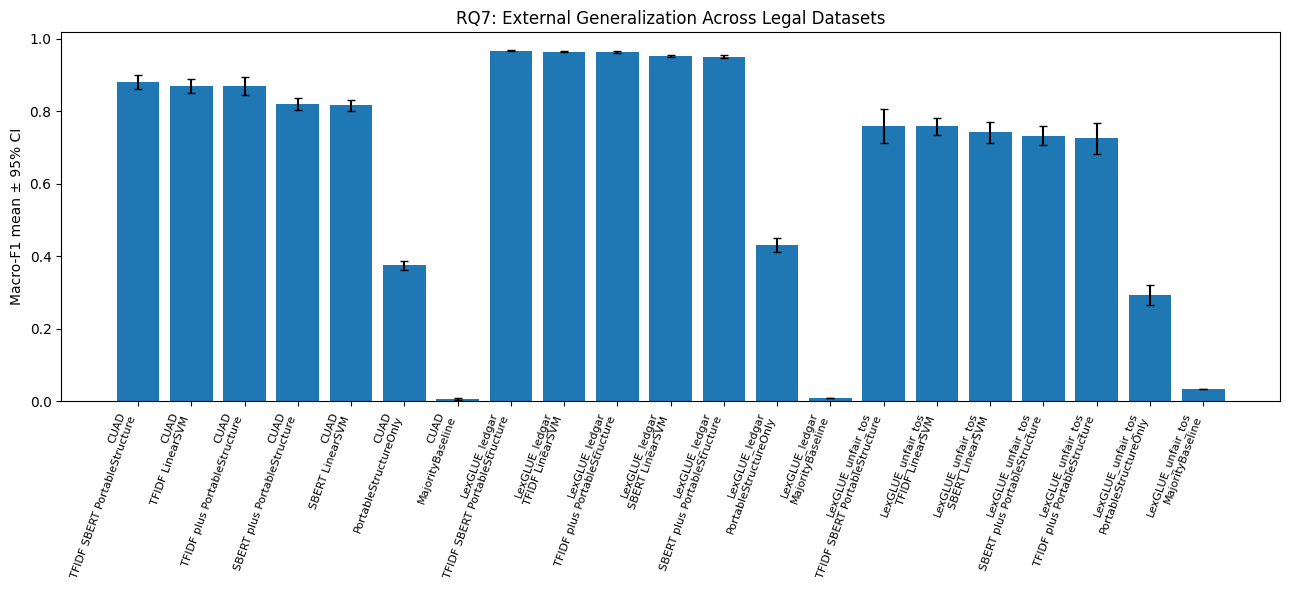

Saved figure: C:\Users\a2510\Desktop\new_code\rq7_journal_strong_outputs\figures\rq7_fig1_external_generalization_macro_f1.pdf


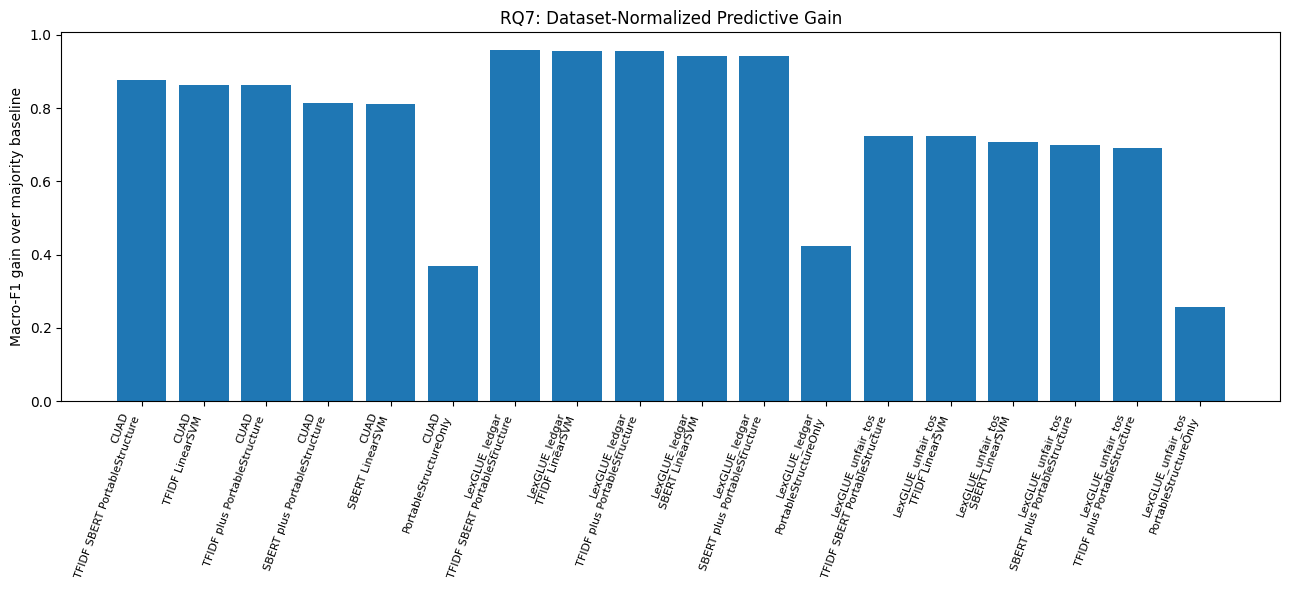

Saved figure: C:\Users\a2510\Desktop\new_code\rq7_journal_strong_outputs\figures\rq7_fig2_gain_over_majority.pdf


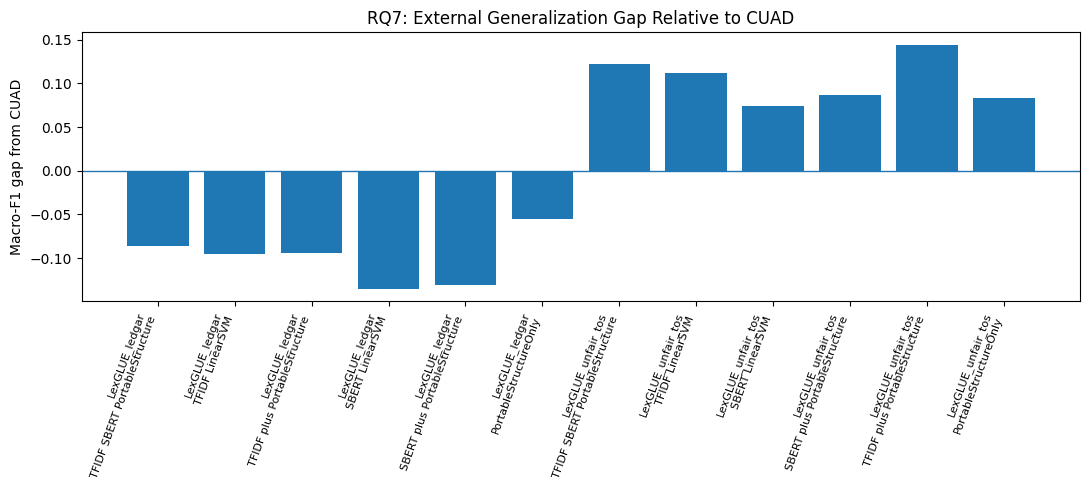

Saved figure: C:\Users\a2510\Desktop\new_code\rq7_journal_strong_outputs\figures\rq7_fig3_generalization_gap_from_cuad.pdf


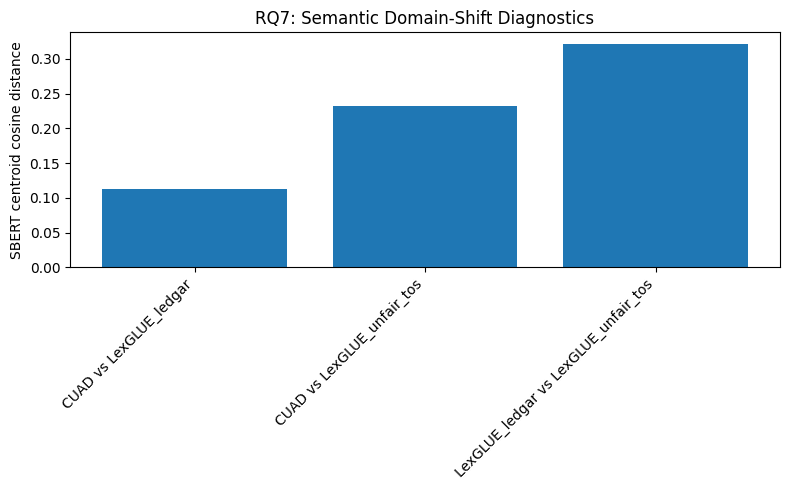

Saved figure: C:\Users\a2510\Desktop\new_code\rq7_journal_strong_outputs\figures\rq7_fig4_domain_shift_centroid_distance.pdf


In [13]:
# ============================================================
# Figures for journal reporting
# ============================================================

plot_df = summary_df.copy()
plt.figure(figsize=(13, 6))
x_labels = []
heights = []
errors = []
for _, row in plot_df.iterrows():
    x_labels.append(row["dataset"] + "\n" + row["model"].replace("_", " "))
    heights.append(row["macro_f1_mean"])
    errors.append(row["macro_f1_ci95"])
plt.bar(range(len(heights)), heights, yerr=errors, capsize=3)
plt.ylabel("Macro-F1 mean ± 95% CI")
plt.title("RQ7: External Generalization Across Legal Datasets")
plt.xticks(range(len(x_labels)), x_labels, rotation=70, ha="right", fontsize=8)
savefig("rq7_fig1_external_generalization_macro_f1.pdf")

gain_plot = gain_df[gain_df["model"] != "MajorityBaseline"].copy()
plt.figure(figsize=(13, 6))
x_labels = []
heights = []
for _, row in gain_plot.iterrows():
    x_labels.append(row["dataset"] + "\n" + row["model"].replace("_", " "))
    heights.append(row["macro_f1_gain_over_majority"])
plt.bar(range(len(heights)), heights)
plt.ylabel("Macro-F1 gain over majority baseline")
plt.title("RQ7: Dataset-Normalized Predictive Gain")
plt.xticks(range(len(x_labels)), x_labels, rotation=70, ha="right", fontsize=8)
savefig("rq7_fig2_gain_over_majority.pdf")

gap_plot = gap_df[(gap_df["dataset"] != "CUAD") & (gap_df["model"] != "MajorityBaseline")].copy()
plt.figure(figsize=(11, 5))
x_labels = []
heights = []
for _, row in gap_plot.iterrows():
    x_labels.append(row["dataset"] + "\n" + row["model"].replace("_", " "))
    heights.append(row["macro_f1_gap_from_cuad"])
plt.axhline(0, linewidth=1)
plt.bar(range(len(heights)), heights)
plt.ylabel("Macro-F1 gap from CUAD")
plt.title("RQ7: External Generalization Gap Relative to CUAD")
plt.xticks(range(len(x_labels)), x_labels, rotation=70, ha="right", fontsize=8)
savefig("rq7_fig3_generalization_gap_from_cuad.pdf")

if not centroid_df.empty:
    plt.figure(figsize=(8, 5))
    labels = centroid_df["dataset_a"] + " vs " + centroid_df["dataset_b"]
    plt.bar(range(len(centroid_df)), centroid_df["sbert_centroid_cosine_distance"])
    plt.ylabel("SBERT centroid cosine distance")
    plt.title("RQ7: Semantic Domain-Shift Diagnostics")
    plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
    savefig("rq7_fig4_domain_shift_centroid_distance.pdf")

In [14]:
# ============================================================
# Journal-ready automatic conclusion helper
# ============================================================

def build_rq7_conclusion(summary_df, gain_df, gap_df, rank_corr_df):
    best_non_dummy = (
        summary_df[summary_df["model"] != "MajorityBaseline"]
        .sort_values(["dataset", "macro_f1_mean"], ascending=[True, False])
        .groupby("dataset")
        .head(1)
    )

    majority = summary_df[summary_df["model"] == "MajorityBaseline"][["dataset", "macro_f1_mean"]]
    best = best_non_dummy.merge(majority, on="dataset", suffixes=("_best", "_majority"))
    best["gain"] = best["macro_f1_mean_best"] - best["macro_f1_mean_majority"]

    lines = []
    lines.append("RQ7 journal-safe conclusion:")
    lines.append("")
    lines.append("The results should be interpreted as evidence of external validity of the portable components of the framework rather than as direct CUAD-to-LexGLUE label transfer.")
    lines.append("Across datasets, the same evaluation protocol was applied to majority, lexical, semantic, and portable-structural variants.")
    lines.append("The strongest model in each dataset and its improvement over the majority baseline are:")
    for _, r in best.iterrows():
        lines.append(
            f"- {r['dataset']}: {r['model']} achieved Macro-F1={r['macro_f1_mean_best']:.3f}, "
            f"improving over the majority baseline by {r['gain']:.3f}."
        )

    if "CUAD" in summary_df["dataset"].values:
        lines.append("")
        lines.append("The generalization-gap table quantifies how far each LexGLUE result is from the CUAD reference result for the same model family. This prevents overstating cross-dataset transfer and makes the domain gap explicit.")

    if rank_corr_df is not None and len(rank_corr_df) > 0:
        mean_corr = rank_corr_df["spearman_model_rank_correlation"].dropna().mean()
        lines.append("")
        lines.append(f"The average model-rank correlation across dataset pairs is {mean_corr:.3f}, indicating the stability of model-family ordering across legal datasets.")

    lines.append("")
    lines.append("Recommended paper wording:")
    lines.append(
        "RQ7 is supported if the portable text/semantic/structural models consistently outperform the majority baseline on CUAD and selected LexGLUE tasks, "
        "while the reported generalization gaps and centroid-distance diagnostics show that the magnitude of performance is dataset-dependent. "
        "Therefore, the framework demonstrates external validity across related legal classification tasks, but not unrestricted cross-task legal reasoning."
    )
    return "\n".join(lines)

conclusion_text = build_rq7_conclusion(summary_df, gain_df, gap_df, rank_corr_df)
print(conclusion_text)

with open(OUT_DIR / "rq7_journal_ready_conclusion.txt", "w", encoding="utf-8") as f:
    f.write(conclusion_text)

print("Saved conclusion:", OUT_DIR / "rq7_journal_ready_conclusion.txt")

RQ7 journal-safe conclusion:

The results should be interpreted as evidence of external validity of the portable components of the framework rather than as direct CUAD-to-LexGLUE label transfer.
Across datasets, the same evaluation protocol was applied to majority, lexical, semantic, and portable-structural variants.
The strongest model in each dataset and its improvement over the majority baseline are:
- CUAD: TFIDF_SBERT_PortableStructure achieved Macro-F1=0.881, improving over the majority baseline by 0.876.
- LexGLUE_ledgar: TFIDF_SBERT_PortableStructure achieved Macro-F1=0.967, improving over the majority baseline by 0.959.
- LexGLUE_unfair_tos: TFIDF_SBERT_PortableStructure achieved Macro-F1=0.759, improving over the majority baseline by 0.725.

The generalization-gap table quantifies how far each LexGLUE result is from the CUAD reference result for the same model family. This prevents overstating cross-dataset transfer and makes the domain gap explicit.

The average model-rank c

## How to write RQ7 in the paper

Use this stronger version:

> **RQ7.** To what extent do the portable components of the proposed lightweight framework maintain predictive value across independent legal datasets, and what external generalization gap is observed between CUAD and selected LexGLUE tasks?

### Claim you can safely make if the results are positive

> The results support RQ7 by showing that the proposed lexical, semantic, and portable structural components retain predictive value across CUAD and selected LexGLUE tasks. All non-trivial model variants are compared against a majority baseline, and performance is reported using repeated splits, Macro-F1 confidence intervals, normalized gain over majority, model-rank stability, and CUAD-to-LexGLUE generalization gaps.

### Claim you should avoid

Do **not** write:

> The CUAD-trained model generalizes to all legal documents.

Instead write:

> The portable components of the framework show external validity across related legal classification datasets, although the magnitude of performance remains dataset-dependent because CUAD, LEDGAR, and UNFAIR-ToS have different label spaces and task definitions.

This makes RQ7 much stronger because the evidence becomes measurable, conservative, and reviewer-safe.